# Classification

In [78]:
import typing

import numpy as np
import numpy.typing as npt
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Метрики классификации

### Accuracy

Доля верных ответов.  

$$ Accuracy = \frac{ N_{correct} } {N} = \frac{ TP + TN } { TP + TN + FP + FN } $$

### Precision:

Точность (доля) положительных предсказаний.  
Метрика тем хуже, чем больше ошибок мы допустили в нашем положительном предсказании.

$$ Precision = \frac{ TP } { TP + FP } $$

### Recall:

Полнота обнаружения положительного класса.  
Метрика тем хуже, чем больше положительных меток мы предсказали неверно (пропустили).

$$ Recall = \frac{ TP } { TP + FN } $$

### F1:

Гармоническое среднее precision и recall.

$$ {"F1-score"} = \frac{ 2 * Precision * Recall } { Precision + Recall } $$

In [79]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-9)


def recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-9)


def f1(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-9)


def report_classification_metrics(y_true, y_pred):
    print(f"Accuracy: {accuracy(y_true, y_pred):.2f}")
    print(f"Precision: {precision(y_true, y_pred):.2f}")
    print(f"Recall: {recall(y_true, y_pred):.2f}")
    print(f"F1-Score: {f1(y_true, y_pred):.2f}")

## Bayes classifiers

In [80]:
# Сгенерируем датасет
X, y = make_blobs(
    n_samples=400,
    centers=2,
    cluster_std=3,
    random_state=42
)

df = pl.DataFrame({
    "x1": X[:, 0],
    "x2": X[:, 1],
    "y": y
})
df.head()

x1,x2,y
f64,f64,i64
7.658757,0.242494,1
5.000766,3.516486,1
5.272931,1.68303,1
-0.964055,20.572481,0
4.165855,0.692526,1


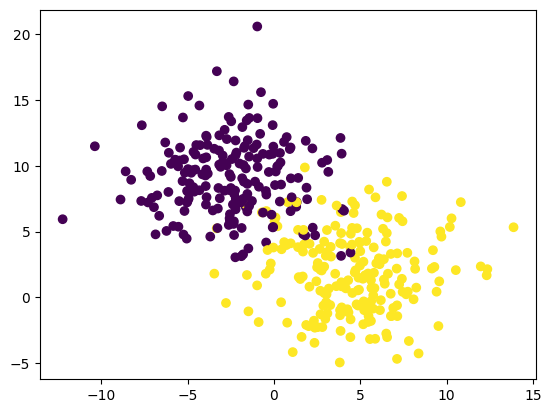

In [81]:
plt.scatter(df["x1"], df["x2"], c=df["y"])

### Gaussian Naive Bayes

Формула Байеса:

$$ P(y|x) = P(y) \prod P(x_j | y) $$

и предполагаем:

$$ P(x_j | y) \sim N(μ, σ²)$$

In [82]:
# extract classes
classes = np.unique(y)
classes

array([0, 1])

In [83]:
# calculate prior probabilities
priors = []
for c in classes:
    prior = len(y[y == c]) / len(y)
    priors.append(prior)

priors

[0.5, 0.5]

In [84]:
# check ourself
df['y'].value_counts()

y,count
i64,u32
1,200
0,200


In [85]:
print("mean no axis:", X.mean())
print("mean with axis 0:", X.mean(axis=0))
print("mean with axis 1:", X.mean(axis=1))

mean no axis: 3.2465668174788562
mean with axis 0: [0.98288938 5.51024426]
mean with axis 1: [ 3.95062567  4.25862596  3.47798079  9.80421302  2.42919081  3.85554772
  1.20205023  2.35050852  4.61729654  1.7050767   5.17674776  5.45234821
  3.73185649  0.55578035  1.44745954  7.03775274  3.5744541   3.60757158
  1.21671428  1.56013244  3.2278051   5.43982862  5.51448151  3.524452
  3.91809422  2.62062584  4.0180715   4.20469574  0.49852016  2.67568751
  1.43356628  2.88251035  5.21275709  5.54577068  5.36403588  5.01263947
  1.59457204  2.33963308  2.15734576  1.62574284  4.79577608  2.20085948
  3.97566961  3.98835082  4.41521158  0.49451184  5.11877409  3.06945241
  1.86286073  7.66173635  1.91905343  6.33067239  2.39914227  2.25605176
  4.19830951  5.80676417  5.18004792  4.65125709  2.4422572   2.88821626
  3.70331838 -0.20126814  6.61737449  2.92186824  5.55444829  3.83358031
  2.05312675  1.77213285  3.75941414  1.73234711  0.6624228   1.75385783
 -1.03077792  3.95165452  1.09387

In [86]:
means = []
variations = []
for c in classes:
    X_for_class = X[y == c]
    mean = X_for_class.mean(axis=0)
    means.append(mean)
    var = X_for_class.var(axis=0)
    variations.append(var)

print("means:", means)
print("variations:", variations)

means: [array([-2.53117472,  9.10149369]), array([4.49695348, 1.91899482])]
variations: [array([8.29944441, 8.2548913 ]), array([9.09397185, 9.03800448])]


In [87]:
# let's calculate P(y=1|x) for some random observation X_obs
class_label = 1
i = np.random.randint(0, len(X))

X_obs, y_obs = X[i], y[i]
X_obs, y_obs

(array([4.45184154, 4.83859665]), np.int64(1))

In [88]:
def gaussian_pdf(x: float, mean: float, var: float) -> float:
    if var == 0:
        var = 1e-10
    exponent = -((x - mean) ** 2) / (2 * var)
    coefficient = 1 / np.sqrt(2 * np.pi * var)
    return coefficient * np.exp(exponent)

In [89]:
likelyhoods = np.empty(len(X_obs))
for x_i in range(len(X_obs)):
    x_i_likelyhood = gaussian_pdf(X_obs[x_i], means[class_label][x_i], variations[class_label][x_i])
    likelyhoods[x_i] = x_i_likelyhood

likelyhoods, likelyhoods.prod()

(array([0.1322771 , 0.08280837]), np.float64(0.010953651025906203))

In [90]:
posteriors = np.empty(len(classes))

for class_label in classes:
    likelyhoods = np.empty(len(X_obs))
    for x_i in range(len(X_obs)):
        x_i_likelyhood = gaussian_pdf(X_obs[x_i], means[class_label][x_i], variations[class_label][x_i])
        likelyhoods[x_i] = x_i_likelyhood

    posteriors[class_label] = priors[class_label] * likelyhoods.prod()

posteriors, np.argmax(posteriors)

(array([0.00016946, 0.00547683]), np.int64(1))

In [91]:
def fit(X: npt.NDArray, y: npt.NDArray) -> typing.Dict[typing.Any, dict]:
    fit_params = {}
    classes = np.unique(y)

    for c in classes:
        X_for_class = X[y == c]

        mean = X_for_class.mean(axis=0)
        var = X_for_class.var(axis=0)
        prior = len(X_for_class) / len(X)

        fit_params[c] = {
            "mean": mean,
            "var": var,
            "prior": prior,
        }

    return fit_params

In [92]:
fit(X, y)

{np.int64(0): {'mean': array([-2.53117472,  9.10149369]),
  'var': array([8.29944441, 8.2548913 ]),
  'prior': 0.5},
 np.int64(1): {'mean': array([4.49695348, 1.91899482]),
  'var': array([9.09397185, 9.03800448]),
  'prior': 0.5}}

In [93]:
# обобщим в виде класса

class GaussianNBManual:
    classes: npt.NDArray
    params: typing.Dict[typing.Any, dict]

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.params = {}

        for c in self.classes:
            Xc = X[y == c]
            self.params[c] = {
                "mean": Xc.mean(axis=0),
                "var": Xc.var(axis=0) + 1e-9,
                "prior": len(Xc)/len(X)
            }

    def predict_proba(self, X):
        probs = []

        for x in X:
            posteriors = []
            for c in self.classes:
                p = self.params[c]["prior"]
                p *= np.prod(self.estimate_likelyhood(x, c))
                posteriors.append(p)

            probs.append(posteriors / np.sum(posteriors))

        return np.array(probs)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def estimate_likelyhood(self, x, class_label):
        mean, var = self.params[class_label]['mean'], self.params[class_label]['var']
        return np.exp(-(x-mean)**2/(2*var)) / np.sqrt(2*np.pi*var)

$$ \log { P(y|x) } \propto \log { P(y) } + \sum_p \log { P(x_j | y) } $$

посмотрим насколько это похоже на реализацию в пакете sklearn: [документация](https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes), [код](https://github.com/scikit-learn/scikit-learn/blob/d3898d9d5/sklearn/naive_bayes.py#L163)

In [94]:
# sklearn simple example

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

report_classification_metrics(y_test, y_pred)

Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1-Score: 0.93


In [95]:
my_classifier = GaussianNBManual()
my_classifier.fit(X_train, y_train)
y_pred = my_classifier.predict(X_test)

report_classification_metrics(y_test, y_pred)

Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1-Score: 0.93


In [96]:
y_proba_manual = classifier.predict_proba(X_test)
y_proba_sklearn = my_classifier.predict_proba(X_test)

prob_diff = np.mean(np.abs(y_proba_manual - y_proba_sklearn))
print(f"Mean absolute probability difference: {prob_diff:.6f}")

Mean absolute probability difference: 0.000000


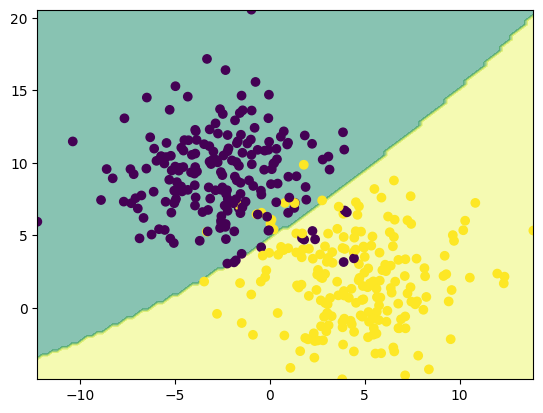

In [97]:
x_axis_min, x_axis_max = X[:, 0].min(), X[:, 0].max()
y_axis_min, y_axis_max = X[:, 1].min(), X[:, 1].max()

xx, yy = np.meshgrid(
    np.linspace(x_axis_min, x_axis_max, 100),
    np.linspace(y_axis_min, y_axis_max, 100))

Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap="summer", alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [98]:
def plot_decision_boundary(classifier, x1, x2, y):
    x_axis_min, x_axis_max = x1.min(), x1.max()
    y_axis_min, y_axis_max = x2.min(), x2.max()

    xx, yy = np.meshgrid(
        np.linspace(x_axis_min, x_axis_max, 100),
        np.linspace(y_axis_min, y_axis_max, 100))

    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="summer", alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.show()

#### Классификация спама


In [99]:
df = pl.read_csv('./spam_ham_dataset.csv')
df.head()

,label,text,label_num
i64,str,str,i64
605,"""ham""","""Subject: enron methanol ; mete…",0
2349,"""ham""","""Subject: hpl nom for january 9…",0
3624,"""ham""","""Subject: neon retreat ho ho h…",0
4685,"""spam""","""Subject: photoshop , windows ,…",1
2030,"""ham""","""Subject: re : indian springs …",0


In [100]:
import string
from wordcloud import STOPWORDS


class TextPreprocessor:
    def __init__(self):
        self.stopwords = STOPWORDS.union(set(['subject', 're', 'enron']))

    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        processed_X = []

        todo = [
            self._lowercase,
            self._remove_punctuation,
            self._remove_stopwords,
        ]

        for text in X:
            for f in todo:
                text = f(text)
            processed_X.append(text)
        
        return np.array(processed_X)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X, y)

    def _lowercase(self, text):
        return text.lower()

    def _remove_punctuation(self, text):
        for punctuation in string.punctuation:
            text = text.replace(punctuation, '')
        return text

    def _remove_stopwords(self, text):
        new_text = []
        for word in text.split():
            if word in self.stopwords:
                continue
            new_text.append(word)
        return ' '.join(new_text)

In [101]:
X = df['text'].to_numpy()
y = df['label_num'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y,
)

pipeline = Pipeline([
    ('text_preprocessor', TextPreprocessor()),
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB(
        alpha=1.0,
        fit_prior=True,
    ))
])

In [102]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       735
           1       0.97      0.95      0.96       300

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035



## Logistic regression

In [103]:
df_raw = pl.read_csv('breast-cancer.csv')
df_raw.head()

id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
842302,"""M""",17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
842517,"""M""",20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902
84300903,"""M""",19.69,21.25,130.0,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
84348301,"""M""",11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173
84358402,"""M""",20.29,14.34,135.1,1297.0,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575.0,0.1374,0.205,0.4,0.1625,0.2364,0.07678


In [104]:
df_raw.get_column("diagnosis").value_counts()

diagnosis,count
str,u32
"""B""",357
"""M""",212


In [105]:
df = df_raw.with_columns(
    pl.col("diagnosis")
      .replace("B", "0")
      .replace("M", "1")
      .cast(pl.Int64)
      .alias("target")
).drop('diagnosis')
df.describe()

statistic,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",3.0372e7,14.127292,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.26919,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
"""std""",1.2502e8,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.07972,0.038803,0.027414,0.00706,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.00617,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
"""min""",8670.0,6.981,9.71,43.79,143.5,0.05263,0.01938,0.0,0.0,0.106,0.04996,0.1115,0.3602,0.757,6.802,0.001713,0.002252,0.0,0.0,0.007882,0.0008948,7.93,12.02,50.41,185.2,0.07117,0.02729,0.0,0.0,0.1565,0.05504,0.0
"""25%""",869218.0,11.7,16.17,75.17,420.3,0.08637,0.06492,0.02956,0.02031,0.1619,0.0577,0.2324,0.8339,1.606,17.85,0.005169,0.01308,0.01509,0.007638,0.01516,0.002248,13.01,21.08,84.11,515.3,0.1166,0.1472,0.1145,0.06493,0.2504,0.07146,0.0
"""50%""",906024.0,13.37,18.84,86.24,551.1,0.09587,0.09263,0.06154,0.0335,0.1792,0.06154,0.3242,1.108,2.287,24.53,0.00638,0.02045,0.02589,0.01093,0.01873,0.003187,14.97,25.41,97.66,686.5,0.1313,0.2119,0.2267,0.09993,0.2822,0.08004,0.0
"""75%""",8.813129e6,15.78,21.8,104.1,782.7,0.1053,0.1304,0.1307,0.074,0.1957,0.06612,0.4789,1.474,3.357,45.19,0.008146,0.03245,0.04205,0.01471,0.02348,0.004558,18.79,29.72,125.4,1084.0,0.146,0.3391,0.3829,0.1614,0.3179,0.09208,1.0
"""max""",9.11320502e8,28.11,39.28,188.5,2501.0,0.1634,0.3454,0.4268,0.2012,0.304,0.09744,2.873,4.885,21.98,542.2,0.03113,0.1354,0.396,0.05279,0.07895,0.02984,36.04,49.54,251.2,4254.0,0.2226,1.058,1.252,0.291,0.6638,0.2075,1.0


In [106]:
TARGET_COLUMN_NAME = "target"

df.get_column(TARGET_COLUMN_NAME).value_counts()

target,count
i64,u32
1,212
0,357


In [107]:
X, y = df.drop(TARGET_COLUMN_NAME).to_numpy(), df.get_column(TARGET_COLUMN_NAME).to_numpy()

X_test, X_train, y_test, y_train = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=0.1,
    ))
])

In [108]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       170
           1       1.00      0.88      0.93       114

    accuracy                           0.95       284
   macro avg       0.96      0.94      0.95       284
weighted avg       0.95      0.95      0.95       284



### ROC-curve

In [109]:
y_scores = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc}")

ROC AUC: 0.9930340557275542


/var/folders/9l/5108yhld00v8d8j4cdr3n7g56cm413/T/ipykernel_46078/3980163150.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='grey')


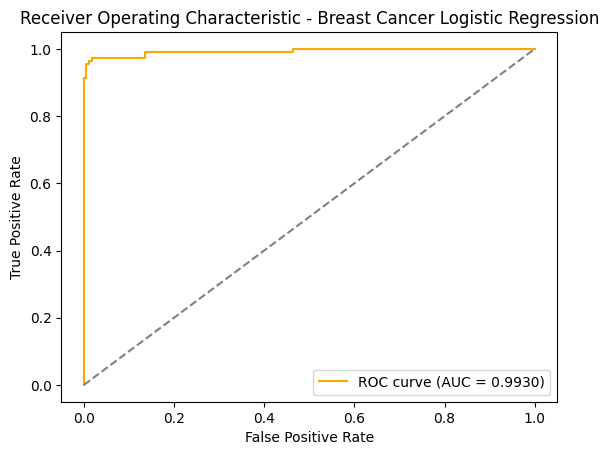

In [110]:
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color='orange')
plt.plot([0, 1], [0, 1], 'k--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Breast Cancer Logistic Regression')
plt.legend(loc="lower right")
plt.show()

### Задача:
Подобрать такой threshold вероятности, чтобы удовлетворять следующему требованию:

$$ TPR (Recall) \ge 99\% $$

То есть требуется с высокой долей уверенности (99% - "2 девятки") обнаруживать рак груди у пациентов, т.к. цена ошибки высока.

In [111]:
print(f"Current recall score: {recall(y_test, y_pred):%}")
print(f"Current F1 score: {f1(y_test, y_pred):.4f}")

Current recall score: 87.719298%
Current F1 score: 0.9346


In [112]:
target_min_tpr = 0.99

best_index = np.argmin(fpr[tpr > target_min_tpr])
best_threshold = thresholds[tpr > target_min_tpr][best_index]

print(f"FPR: {fpr[tpr > target_min_tpr][best_index]:.4f}")
print(f"TPR: {tpr[tpr > target_min_tpr][best_index]:.4f}")
print(f"Threshold: {best_threshold:.4f}")

FPR: 0.1353
TPR: 0.9912
Threshold: 0.1221


In [113]:
y_pred_new = (y_scores >= best_threshold).astype(int)

print("Before tweaking threshold:")
report_classification_metrics(y_test, y_pred)

print("\nWith tweaked threshold:")
report_classification_metrics(y_test, y_pred_new)

Before tweaking threshold:
Accuracy: 0.95
Precision: 1.00
Recall: 0.88
F1-Score: 0.93

With tweaked threshold:
Accuracy: 0.92
Precision: 0.83
Recall: 0.99
F1-Score: 0.90


## One vs All classifier

In [114]:
X, y = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=2,
    random_state=42,
)

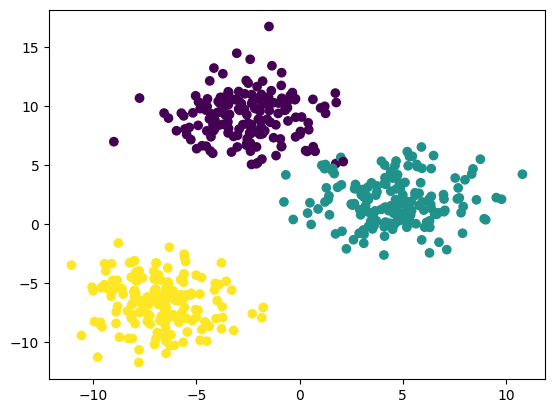

In [115]:
plt.scatter(X[:,0], X[:,1], c=y)

In [116]:
class OneVsAllClassifier:
    def __init__(self, base_clf):
        self.base_clf = base_clf

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.models = {}

        for c in self.classes:
            y_bin = (y == c).astype(int)
            clf = self.base_clf()
            clf.fit(X, y_bin)
            self.models[c] = clf

    def predict(self, X):
        scores = np.column_stack([
            self.models[c].predict_proba(X)[:,1]
            for c in self.classes
        ])
        return np.argmax(scores, axis=1)

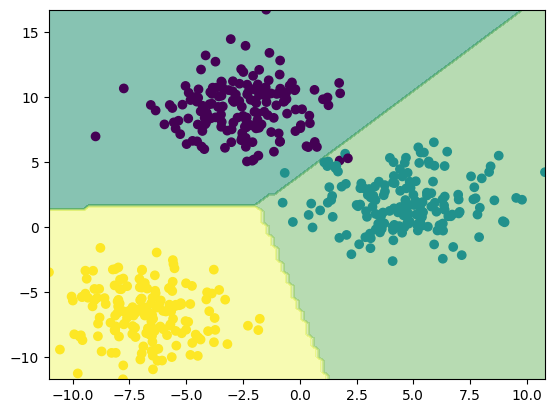

In [117]:
classifier = OneVsAllClassifier(lambda: LogisticRegression())
classifier.fit(X, y)

plot_decision_boundary(classifier, X[:, 0], X[:, 1], y)